In [1]:
import torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU — enable T4!")
print("CUDA:", torch.version.cuda)

GPU: Tesla T4
CUDA: 12.8


In [2]:
!pip install -q torch torchvision matplotlib seaborn scikit-learn pillow tqdm opencv-python-headless


In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os
BASE = "/content/drive/MyDrive/disease_data"

for folder in ["bone_fracture", "knee", "dental"]:
    path = os.path.join(BASE, folder)
    print(f"  {folder}: {'✅' if os.path.exists(path) else '❌ NOT FOUND'}")



Mounted at /content/drive
  bone_fracture: ✅
  knee: ✅
  dental: ✅


In [4]:
import os, random, shutil, json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
import cv2

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, models
from sklearn.metrics import classification_report, confusion_matrix

torch.manual_seed(42); np.random.seed(42); random.seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)


Device: cuda


In [5]:
class SimpleDataset(Dataset):
    def __init__(self, root, transform=None):
        self.samples=[]; self.transform=transform
        self.classes=sorted([d for d in os.listdir(root)
                             if os.path.isdir(os.path.join(root,d))])
        self.class_to_idx={c:i for i,c in enumerate(self.classes)}
        for cls in self.classes:
            d=os.path.join(root,cls)
            for f in os.listdir(d):
                if f.lower().endswith(('.jpg','.jpeg','.png')):
                    self.samples.append((os.path.join(d,f),
                                         self.class_to_idx[cls]))
    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        p,l=self.samples[idx]
        try: img=Image.open(p).convert('RGB')
        except: img=Image.new('RGB',(224,224),0)
        if self.transform: img=self.transform(img)
        return img,l

train_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2,contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])

def build_resnet(num_classes):
    m=models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    for n,p in m.named_parameters():
        if "layer4" not in n and "fc" not in n: p.requires_grad=False
    m.fc=nn.Sequential(nn.Dropout(0.4),nn.Linear(m.fc.in_features,512),
                        nn.ReLU(),nn.Dropout(0.3),nn.Linear(512,num_classes))
    return m

def train_epoch(model,loader,criterion,optimizer):
    model.train(); tl,correct,total=0,0,0
    for imgs,labels in tqdm(loader,desc="  Train",leave=False):
        imgs,labels=imgs.to(device),labels.to(device)
        optimizer.zero_grad(); out=model(imgs)
        loss=criterion(out,labels); loss.backward(); optimizer.step()
        tl+=loss.item(); correct+=(out.argmax(1)==labels).sum().item()
        total+=labels.size(0)
    return tl/len(loader),correct/total

def val_epoch(model,loader,criterion):
    model.eval(); tl,correct,total=0,0,0
    with torch.no_grad():
        for imgs,labels in tqdm(loader,desc="  Val  ",leave=False):
            imgs,labels=imgs.to(device),labels.to(device)
            out=model(imgs); tl+=criterion(out,labels).item()
            correct+=(out.argmax(1)==labels).sum().item(); total+=labels.size(0)
    return tl/len(loader),correct/total

def train_model(model,train_loader,val_loader,criterion,epochs_p1=10,epochs_p2=5,
                save_path="/content/best.pth"):
    best_acc=0.0; history={k:[] for k in ["tl","vl","ta","va"]}
    optimizer=optim.AdamW(filter(lambda p:p.requires_grad,model.parameters()),
                          lr=1e-4,weight_decay=1e-4)
    scheduler=optim.lr_scheduler.CosineAnnealingLR(optimizer,T_max=epochs_p1,eta_min=1e-6)

    print("PHASE 1 — frozen backbone")
    for epoch in range(1,epochs_p1+1):
        tl,ta=train_epoch(model,train_loader,criterion,optimizer)
        vl,va=val_epoch(model,val_loader,criterion); scheduler.step()
        for k,v in zip(history,[tl,vl,ta,va]): history[k].append(v)
        flag=""
        if va>best_acc: best_acc=va; torch.save(model.state_dict(),save_path); flag="  ← best"
        print(f"  Epoch {epoch:02d}/{epochs_p1} | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")

    # Phase 2
    model.load_state_dict(torch.load(save_path))
    for p in model.parameters(): p.requires_grad=True
    opt2=optim.AdamW(model.parameters(),lr=3e-5,weight_decay=1e-4)
    sch2=optim.lr_scheduler.CosineAnnealingLR(opt2,T_max=epochs_p2,eta_min=1e-7)

    print("PHASE 2 — full fine-tuning")
    for epoch in range(1,epochs_p2+1):
        tl,ta=train_epoch(model,train_loader,criterion,opt2)
        vl,va=val_epoch(model,val_loader,criterion); sch2.step()
        for k,v in zip(history,[tl,vl,ta,va]): history[k].append(v)
        flag=""
        if va>best_acc: best_acc=va; torch.save(model.state_dict(),save_path); flag="  ← best"
        print(f"  Epoch {epoch:02d}/{epochs_p2} | Train {ta*100:.2f}% | Val {va*100:.2f}%{flag}")

    print(f"\nBest val accuracy: {best_acc*100:.2f}%")
    return best_acc, history

def save_to_drive(files, save_dir="/content/drive/MyDrive/medical_ai_models"):
    os.makedirs(save_dir, exist_ok=True)
    for fp in files:
        if os.path.exists(fp):
            shutil.copy2(fp, os.path.join(save_dir, os.path.basename(fp)))
            print(f"  Saved: {os.path.basename(fp)}")

print("Shared utilities ready.")


Shared utilities ready.


In [ ]:
# ── BUILD BONE DATASET (FIXED) ──────────────────────────────────────────
# FIXES:
#  1. Normal_Bone → ONLY knee/0Normal (clean labels; YOLO images are mixed!)
#  2. Fracture    → both YOLO v4 splits for more samples
#  3. Minority classes (Osteo*) capped at 2000 each to reduce imbalance
# ========================================================================
BONE_BASE   = f"{BASE}/bone_fracture/BoneFractureYolo8"
BONE_V4     = f"{BASE}/bone_fracture/bone fracture detection.v4-v4.yolov8"
KNEE_BASE   = f"{BASE}/knee/MedicalExpert-I"
BONE_OUT    = "/content/bone_combined"
BONE_CLASSES = ["Fracture", "Normal_Bone", "Osteoarthritis", "Osteoporosis"]

import shutil
for cls in BONE_CLASSES:
    if os.path.exists(f"{BONE_OUT}/{cls}"):
        shutil.rmtree(f"{BONE_OUT}/{cls}")
    os.makedirs(f"{BONE_OUT}/{cls}")

def copy_imgs(src, dest, limit=2000, tag=""):
    if not os.path.exists(src):
        print(f"  [SKIP] {src}"); return 0
    files = [f for f in os.listdir(src) if f.lower().endswith(('.jpg','.jpeg','.png'))]
    random.shuffle(files)
    files = files[:limit]
    for i, f in enumerate(tqdm(files, desc=f"  {tag}", leave=False)):
        shutil.copy2(os.path.join(src, f),
                     f"{dest}/{tag}_{i:05d}{os.path.splitext(f)[1]}")
    return len(files)

print("Building Bone Disease dataset (FIXED)...\n")

# Normal_Bone — ONLY clean knee normal images (YOLO folders mix fractured+normal)
n = copy_imgs(f"{KNEE_BASE}/0Normal", f"{BONE_OUT}/Normal_Bone", 2500, "knee_normal")
print(f"  Normal_Bone: {n}  ✅ clean labels")

# Fracture — use v4 dataset (labelled fracture-only splits)
f1 = copy_imgs(f"{BONE_V4}/train/images", f"{BONE_OUT}/Fracture", 2000, "frac_train")
f2 = copy_imgs(f"{BONE_V4}/valid/images", f"{BONE_OUT}/Fracture",  500, "frac_valid")
f3 = copy_imgs(f"{BONE_V4}/test/images",  f"{BONE_OUT}/Fracture",  500, "frac_test") \
     if os.path.exists(f"{BONE_V4}/test/images") else 0
print(f"  Fracture: {f1+f2+f3}")

# Osteoporosis — use ALL available severe grades
o1 = copy_imgs(f"{KNEE_BASE}/3Moderate", f"{BONE_OUT}/Osteoporosis", 2000, "osteo_mod")
o2 = copy_imgs(f"{KNEE_BASE}/4Severe",   f"{BONE_OUT}/Osteoporosis", 2000, "osteo_sev")
print(f"  Osteoporosis: {o1+o2}")

# Osteoarthritis — use ALL available mild grades
a1 = copy_imgs(f"{KNEE_BASE}/1Doubtful", f"{BONE_OUT}/Osteoarthritis", 2000, "oa_doubt")
a2 = copy_imgs(f"{KNEE_BASE}/2Mild",     f"{BONE_OUT}/Osteoarthritis", 2000, "oa_mild")
print(f"  Osteoarthritis: {a1+a2}")

print("\nFinal bone dataset:")
for cls in BONE_CLASSES:
    print(f"  {cls:20s}: {len(os.listdir(f'{BONE_OUT}/{cls}'))}")


In [ ]:
# ── TRAIN BONE MODEL (FIXED) ─────────────────────────────────────────────
# FIXES:
#  1. Proper train/val split — two separate dataset objects (no transform leakage)
#  2. Stronger X-ray augmentation + RandomErasing
#  3. Label smoothing (0.1) + sqrt-scaled class weights
#  4. More epochs: 15 phase1 + 10 phase2 = 25 total
# =========================================================================
from torch.utils.data import Subset
from collections import Counter

bone_train_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.4, saturation=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225]),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15))
])

bone_val_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# Proper split: separate dataset instances to avoid transform leakage
bone_full   = SimpleDataset(BONE_OUT, transform=None)
n_total     = len(bone_full)
val_size    = int(0.15 * n_total)
all_idx     = list(range(n_total))
random.seed(42)
random.shuffle(all_idx)
train_idx   = all_idx[val_size:]
val_idx     = all_idx[:val_size]

bone_train_ds = SimpleDataset(BONE_OUT, transform=bone_train_tf)
bone_val_ds   = SimpleDataset(BONE_OUT, transform=bone_val_tf)
tr_bone       = Subset(bone_train_ds, train_idx)
vl_bone       = Subset(bone_val_ds,   val_idx)

tr_bone_loader = DataLoader(tr_bone, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
vl_bone_loader = DataLoader(vl_bone, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

bone_classes = bone_full.classes
bone_counts  = Counter([bone_full.samples[i][1] for i in train_idx])

total = sum(bone_counts.values())
bone_weights = torch.tensor(
    [(total / (len(bone_classes) * bone_counts[i])) ** 0.75
     for i in range(len(bone_classes))], dtype=torch.float).to(device)

bone_criterion = nn.CrossEntropyLoss(weight=bone_weights, label_smoothing=0.1)
bone_model     = build_resnet(len(bone_classes)).to(device)

print("="*55)
print(f"BONE DISEASE MODEL (FIXED) — {len(bone_classes)} classes")
print(f"Classes : {bone_classes}")
print(f"Train: {len(tr_bone)} | Val: {len(vl_bone)}")
print("Class distribution (train):")
for i, cls in enumerate(bone_classes):
    print(f"  {cls:20s}: {bone_counts[i]}")
print("="*55)

best_bone, bone_history = train_model(
    bone_model, tr_bone_loader, vl_bone_loader,
    bone_criterion,
    epochs_p1=15,    # was 10
    epochs_p2=10,    # was 5
    save_path="/content/bone_best.pth")


Eval: 100%|██████████| 29/29 [00:07<00:00,  4.02it/s]


                precision    recall  f1-score   support

      Fracture       0.56      0.93      0.70       378
   Normal_Bone       0.65      0.19      0.30       359
Osteoarthritis       0.83      0.85      0.84       105
  Osteoporosis       0.92      0.93      0.93        60

      accuracy                           0.63       902
     macro avg       0.74      0.73      0.69       902
  weighted avg       0.65      0.63      0.57       902



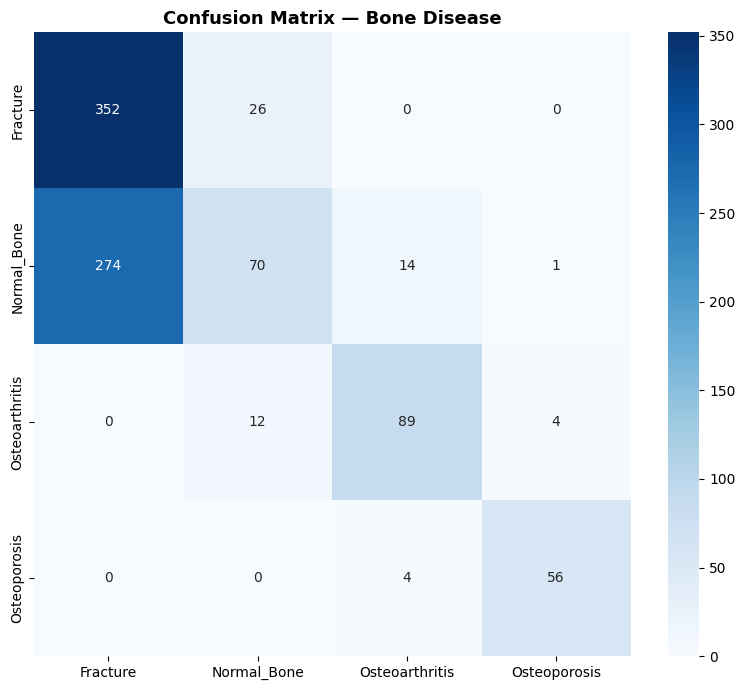

  Saved: bone_model.pth
  Saved: bone_metadata.json
  Saved: bone_cm.png
✅ Bone model done — 62.86%


In [9]:
bone_model.load_state_dict(torch.load("/content/bone_best.pth"))
bone_model.eval()
all_p,all_l=[],[]
with torch.no_grad():
    for imgs,labels in tqdm(vl_bone_loader,desc="Eval"):
        all_p.extend(bone_model(imgs.to(device)).argmax(1).cpu().numpy())
        all_l.extend(labels.numpy())

print(classification_report(all_l,all_p,target_names=bone_classes))
cm=confusion_matrix(all_l,all_p)
fig,ax=plt.subplots(figsize=(8,7))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=bone_classes,yticklabels=bone_classes,ax=ax)
ax.set_title("Confusion Matrix — Bone Disease",fontsize=13,fontweight='bold')
plt.tight_layout(); plt.savefig("/content/bone_cm.png",dpi=120); plt.show()

torch.save(bone_model.state_dict(),"/content/bone_model.pth")
bone_metadata={
    "model_name":"ResNet50 Bone Disease Detector",
    "num_classes":len(bone_classes),"classes":bone_classes,
    "class_to_idx":{c:i for i,c in enumerate(bone_classes)},
    "input_size":[224,224],
    "normalize_mean":[0.485,0.456,0.406],
    "normalize_std":[0.229,0.224,0.225],
    "best_val_accuracy":round(best_bone*100,2),
    "scan_type":"X-ray",
    "disease_info":{
        "Normal_Bone":{
            "description":"Normal healthy bone structure with no abnormalities detected.",
            "symptoms":["No symptoms"],"treatment":"No treatment required",
            "risk":"None","emergency":False
        },
        "Fracture":{
            "description":"A break or crack in a bone caused by trauma, stress, or disease.",
            "symptoms":["Severe pain","Swelling","Bruising","Deformity","Inability to move"],
            "treatment":"Immobilization (cast/splint), surgery for complex fractures, physiotherapy",
            "risk":"Moderate-High","emergency":True
        },
        "Osteoporosis":{
            "description":"Reduced bone density making bones weak and more prone to fractures.",
            "symptoms":["Back pain","Loss of height","Stooped posture","Fragility fractures"],
            "treatment":"Calcium+Vitamin D, bisphosphonates (alendronate), lifestyle changes, weight-bearing exercise",
            "risk":"Moderate","emergency":False
        },
        "Osteoarthritis":{
            "description":"Degenerative joint disease causing cartilage breakdown and bone changes.",
            "symptoms":["Joint pain","Stiffness","Swelling","Reduced range of motion","Grating sensation"],
            "treatment":"Pain management (NSAIDs), physiotherapy, weight loss, joint replacement if severe",
            "risk":"Moderate","emergency":False
        }
    }
}
with open("/content/bone_metadata.json","w") as f: json.dump(bone_metadata,f,indent=2)
save_to_drive(["/content/bone_model.pth","/content/bone_metadata.json","/content/bone_cm.png"])
print(f"✅ Bone model done — {best_bone*100:.2f}%")

